# Лабораторна 7 - Реалізація PCA та SVD

**Курс:** Машинне навчання. Частина 2  
**Тиждень:** 7  
**Тема лабораторної:** Реалізація алгоритмів PCA та SVD

## Цілі лабораторної

- PCA: fit, transform, inverse_transform 
- Пояснена дисперсія та вибір кількості компонент 
- TruncatedSVD та еквівалентність з PCA 
- Власні обличчя (Eigenfaces) 
- Шумоподавлення сигналів за допомогою SVD


## Налаштування середовища

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Jupyter display
%matplotlib inline

# Reproducibility
np.random.seed(42)

# Add course modules to path
import sys
from pathlib import Path

course_root = Path.cwd()
if 'course' in course_root.parts:
    while course_root.name != 'course' and course_root.parent != course_root:
        course_root = course_root.parent
else:
    course_root = course_root / 'course'

modules_path = course_root / 'modules'
if str(modules_path) not in sys.path:
    sys.path.insert(0, str(modules_path))

# Apply shared colorblind-safe plot style
from plot_style import setup_plot_style, COLORBLIND_PALETTE
setup_plot_style()

import numpy as np
import matplotlib.pyplot as plt
import importlib
import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import fetch_olivetti_faces, make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression as SklearnLR
from sklearn.metrics import accuracy_score

import pca_svd_student as dr
importlib.reload(dr)

SEED = 42
np.random.seed(SEED)

COLORS = ["#2C7BB6", "#D7191C", "#1A9641", "#FDAE61", "#762A83"]


---
## 1. - PCA: fit, transform, inverse_transform

### Алгоритм PCA

Нехай $X \in \mathbb{R}^{n \times d}$ - матриця даних (рядки - об'єкти, стовпці - ознаки).

| Крок | Дія |
|------|-----|
| 1 | Центрування: $\mu_j = \frac{1}{n}\sum_i x_{ij}$, $\tilde{X} = X - \mathbf{1}\mu^\top$ |
| 2 | Коваріаційна матриця: $C = \dfrac{1}{n-1}\tilde{X}^\top \tilde{X} \in \mathbb{R}^{d \times d}$ |
| 3 | Власний розклад: $C v_i = \lambda_i v_i$ (через `np.linalg.eigh`) |
| 4 | Сортування: $\lambda_1 \geq \lambda_2 \geq \ldots \geq \lambda_d$ |
| 5 | Вибір $k$ векторів: $V_k \in \mathbb{R}^{d \times k}$ (перші $k$ стовпців) |
| 6 | Проекція: $Z = \tilde{X} V_k \in \mathbb{R}^{n \times k}$ |
| 7 | Реконструкція: $\hat{X} = Z V_k^\top + \mu^\top$ |

Реалізуйте методи `fit`, `transform`, `fit_transform`, `inverse_transform`
та `reconstruction_error` класу `PCA` у файлі `pca_svd_student.py`.

#### Завдання 1a–1d: базові перевірки PCA

Реалізуйте `fit`, `transform`, `fit_transform` та `inverse_transform` у класі `PCA`.
Клітинка нижче перевіряє розміри вихідних масивів, ортонормальність компонент і форму реконструкції.

In [2]:
importlib.reload(dr)

# ── 1a. Shape test ────────────────────────────────────────────────────────────
rng = np.random.default_rng(SEED)
X_test = rng.normal(size=(80, 12))
X_test = StandardScaler().fit_transform(X_test)

pca = dr.PCA(n_components=4)
Z   = pca.fit_transform(X_test)

print(f"Input shape:      {X_test.shape}")
print(f"Projection shape: {Z.shape}          expected (80, 4)")
assert Z.shape == (80, 4), f"Expected (80, 4), got {Z.shape}"
print("✓ fit_transform shape OK")

# ── 1b. Components shape ──────────────────────────────────────────────────────
assert pca.components_.shape == (4, 12), \
    f"components_ should be (4, 12), got {pca.components_.shape}"
print("✓ components_ shape OK")

# ── 1c. Orthonormality of components ──────────────────────────────────────────
VVt = pca.components_ @ pca.components_.T    # should be identity
assert np.allclose(VVt, np.eye(4), atol=1e-8), \
    "Principal components are not orthonormal"
print("✓ components_ are orthonormal (V @ V.T ≈ I)")

# ── 1d. Reconstruction ────────────────────────────────────────────────────────
X_hat = pca.inverse_transform(Z)
assert X_hat.shape == X_test.shape, "inverse_transform shape mismatch"
print("✓ inverse_transform shape OK")

Input shape:      (80, 12)
Projection shape: (80, 4)          expected (80, 4)
✓ fit_transform shape OK
✓ components_ shape OK
✓ components_ are orthonormal (V @ V.T ≈ I)
✓ inverse_transform shape OK


#### Завдання 1e: похибка реконструкції

Реалізуйте `reconstruction_error`. Перевірте, що зі збільшенням $k$ похибка монотонно спадає.

✓ Reconstruction error is non-increasing with k


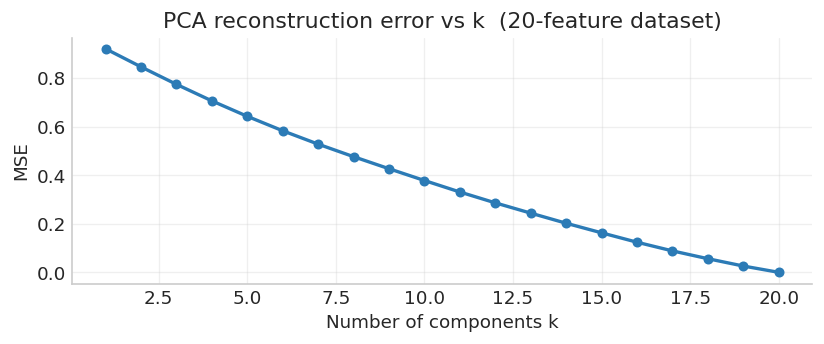

In [3]:
importlib.reload(dr)

# ── 1e. Reconstruction error decreases as k grows ─────────────────────────────
rng = np.random.default_rng(SEED)
X_err = StandardScaler().fit_transform(rng.normal(size=(200, 20)))

k_vals, errors = range(1, 21), []
for k in k_vals:
    p = dr.PCA(n_components=k)
    p.fit(X_err)
    errors.append(p.reconstruction_error(X_err))

# Verify monotone decrease
assert all(errors[i] >= errors[i+1] - 1e-10 for i in range(len(errors)-1)), \
    "Reconstruction error should be non-increasing with k"
print("✓ Reconstruction error is non-increasing with k")

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(list(k_vals), errors, marker='o', color=COLORS[0], lw=2, markersize=5)
ax.set_xlabel("Number of components k"); ax.set_ylabel("MSE")
ax.set_title("PCA reconstruction error vs k  (20-feature dataset)")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

#### Що ви маєте бачити

Графік MSE vs $k$ повинен монотонно спадати та наближатись до нуля при $k = d$.
При малих $k$ спад крутий - перші компоненти пояснюють найбільшу частку дисперсії.
Після певного «ліктя» кожна наступна компонента дає дедалі менший приріст - саме тут
варто зупинитись на практиці.

#### Завдання 1f: перевірка відносно sklearn

Переконайтесь, що ваші проекції збігаються з еталонною реалізацією `sklearn.decomposition.PCA`.
Знак власного вектора не визначений однозначно, тому порівнюємо абсолютні значення.

In [4]:
importlib.reload(dr)

# ── 1f. PCA projection vs sklearn sanity check ───────────────────────────────
from sklearn.decomposition import PCA as SklearnPCA

rng = np.random.default_rng(SEED)
X_chk = StandardScaler().fit_transform(rng.normal(size=(50, 6)))

our_pca = dr.PCA(n_components=3)
Z_ours  = our_pca.fit_transform(X_chk)

sk_pca  = SklearnPCA(n_components=3, random_state=SEED)
Z_sk    = sk_pca.fit_transform(X_chk)

# Compare absolute values (sign of eigenvectors can differ)
diff = np.abs(np.abs(Z_ours) - np.abs(Z_sk)).max()
print(f"Max |abs difference| vs sklearn PCA projections: {diff:.2e}")
assert diff < 1e-6, f"Too large: {diff}"
print("✓ Projections match sklearn PCA (up to sign)")

Max |abs difference| vs sklearn PCA projections: 2.91e-14
✓ Projections match sklearn PCA (up to sign)


#### Що ви маєте бачити

Максимальна різниця між вашою проекцією та проекцією sklearn має бути порядку $10^{-8}$ або менше.
Якщо різниця більша - перевірте порядок сортування власних значень та транспонування компонент.

---
## 2. - Пояснена дисперсія та вибір кількості компонент $k$

Частка дисперсії, пояснена $k$ компонентами:

$$\text{EVR}(k) = \frac{\sum_{i=1}^{k} \lambda_i}{\sum_{i=1}^{d} \lambda_i}$$

Практичний критерій вибору $k$: знайти мінімальне $k$, при якому накопичена EVR $\geq$ порогу (зазвичай 90–95%).

Нижче ми застосуємо PCA до датасету рукописних цифр (784 ознаки) та визначимо
оптимальну кількість компонент.

#### Завдання Part 2: вибір кількості компонент

Застосуйте `PCA` (без `n_components`, тобто зберігаючи всі компоненти) до датасету цифр
та побудуйте scree plot. Потім виміряйте точність класифікатора при різних $k$ і порівняйте
з базовою лінією на всіх ознаках.

Digits dataset: 1797 samples, 64 features
Components for 90% EVR: 31
Components for 95% EVR: 40


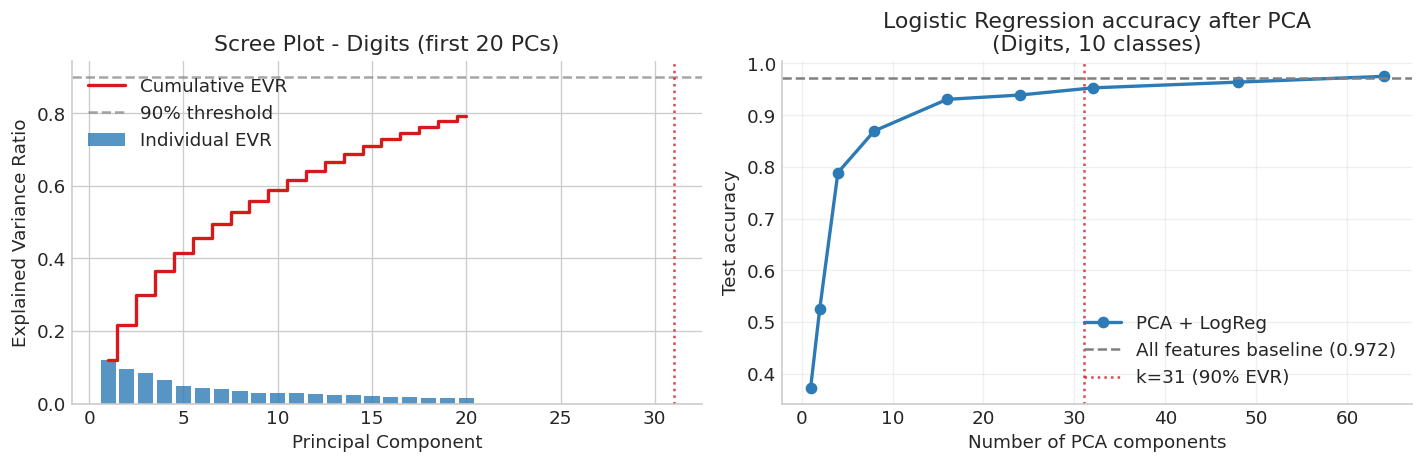

Baseline (all 64 features):  0.972
PCA k=31 (90% EVR):       0.953


In [5]:
importlib.reload(dr)
from sklearn.datasets import load_digits

digits = load_digits()
X_dig  = StandardScaler().fit_transform(digits.data.astype(float))
y_dig  = digits.target
print(f"Digits dataset: {X_dig.shape[0]} samples, {X_dig.shape[1]} features")

# Fit PCA keeping all components to examine the scree plot
pca_full = dr.PCA(n_components=None)
pca_full.fit(X_dig)

evr     = pca_full.explained_variance_ratio_
cum_evr = np.cumsum(evr)

# Minimum k for 90% and 95% explained variance
k90 = np.searchsorted(cum_evr, 0.90) + 1
k95 = np.searchsorted(cum_evr, 0.95) + 1
print(f"Components for 90% EVR: {k90}")
print(f"Components for 95% EVR: {k95}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scree plot
axes[0].bar(range(1, 21), evr[:20], color=COLORS[0], alpha=0.8, label="Individual EVR")
axes[0].step(range(1, 21), cum_evr[:20], where='mid', color=COLORS[1], lw=2,
             label="Cumulative EVR")
axes[0].axhline(0.9, linestyle='--', color='gray', alpha=0.7, label="90% threshold")
axes[0].axvline(k90, linestyle=':', color=COLORS[1], alpha=0.8)
axes[0].set_xlabel("Principal Component"); axes[0].set_ylabel("Explained Variance Ratio")
axes[0].set_title("Scree Plot - Digits (first 20 PCs)"); axes[0].legend()

# Classification accuracy vs k
accs = []
X_tr_d, X_te_d, y_tr_d, y_te_d = train_test_split(
    X_dig, y_dig, test_size=0.2, random_state=SEED, stratify=y_dig)

k_range = [1, 2, 4, 8, 16, 24, 32, 48, 64]
for k in k_range:
    p = dr.PCA(n_components=k)
    Z_tr = p.fit_transform(X_tr_d)
    Z_te = p.transform(X_te_d)
    clf = SklearnLR(max_iter=500, random_state=SEED)
    clf.fit(Z_tr, y_tr_d)
    accs.append(accuracy_score(y_te_d, clf.predict(Z_te)))

# Baseline: logistic regression on all 64 features
clf_base = SklearnLR(max_iter=500, random_state=SEED)
clf_base.fit(X_tr_d, y_tr_d)
baseline = accuracy_score(y_te_d, clf_base.predict(X_te_d))

axes[1].plot(k_range, accs, marker='o', color=COLORS[0], lw=2, label="PCA + LogReg")
axes[1].axhline(baseline, linestyle='--', color='gray', lw=1.5,
                label=f"All features baseline ({baseline:.3f})")
axes[1].axvline(k90, linestyle=':', color=COLORS[1], alpha=0.8, label=f"k={k90} (90% EVR)")
axes[1].set_xlabel("Number of PCA components"); axes[1].set_ylabel("Test accuracy")
axes[1].set_title("Logistic Regression accuracy after PCA\n(Digits, 10 classes)")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()
print(f"Baseline (all 64 features):  {baseline:.3f}")
print(f"PCA k={k90} (90% EVR):       {accs[k_range.index(k_range[np.searchsorted(k_range, k90)])]:.3f}")

#### Що ви маєте бачити

**Scree plot (ліворуч):** перші 10–15 компонент пояснюють переважну більшість дисперсії;
крива «лікоть» добре помітна. Порогу 90% EVR відповідає $k \approx 25-30$ компонент
замість вихідних 64.

**Accuracy vs $k$ (праворуч):** точність швидко зростає при малих $k$, досягає піку
десь у зоні 90% EVR і далі майже не змінюється або дещо спадає через шум.
Важливо, що $k \approx 20-30$ компонент дає точність, порівнянну з усіма 64 ознаками,
а інколи навіть вищу - PCA прибирає шумові виміри, що заважають класифікатору.

---
## 3. - TruncatedSVD та еквівалентність з PCA

### Алгоритм Truncated SVD

Повний SVD: $X = U \Sigma V^\top$, де $\sigma_1 \geq \sigma_2 \geq \ldots$

**Truncated SVD** зберігає лише перші $k$ триплетів:

$$\hat{X}_k = U_k \Sigma_k V_k^\top = \sum_{i=1}^{k} \sigma_i \mathbf{u}_i \mathbf{v}_i^\top$$

**Зв'язок з PCA на центрованих даних:**
* Стовпці $V_k$ (рядки `components_`) - ті самі напрямки, що й у PCA
* $\lambda_i = \sigma_i^2 / (n-1)$ - власні значення коваріаційної матриці
* Проекції $Z$ збігаються з точністю до знаку

**Коли краще SVD:** для розріджених матриць (TF-IDF, рекомендаційні системи),
де центрування знищило б розрідженість.

Реалізуйте методи `fit`, `transform`, `fit_transform`, `inverse_transform`
та `reconstruction_error` класу `TruncatedSVD`.

#### Завдання 3a: базові перевірки TruncatedSVD

Реалізуйте `fit`, `transform`, `fit_transform`, `inverse_transform` та `reconstruction_error`
у класі `TruncatedSVD`. Клітинка нижче перевіряє розміри масивів і порядок сингулярних значень.

In [6]:
importlib.reload(dr)

# ── 3a. Basic shape test ──────────────────────────────────────────────────────
rng = np.random.default_rng(SEED)
X_svd = StandardScaler().fit_transform(rng.normal(size=(60, 10)))

svd = dr.TruncatedSVD(n_components=3)
Z_svd = svd.fit_transform(X_svd)

assert Z_svd.shape == (60, 3), f"Expected (60, 3), got {Z_svd.shape}"
print("✓ fit_transform shape OK")

assert svd.components_.shape == (3, 10), \
    f"components_ should be (3, 10), got {svd.components_.shape}"
print("✓ components_ shape OK")

# Singular values must be non-negative and descending
assert (svd.singular_values_ >= 0).all(), "Singular values must be non-negative"
assert all(svd.singular_values_[i] >= svd.singular_values_[i+1]
           for i in range(len(svd.singular_values_)-1)), \
    "Singular values must be in descending order"
print("✓ singular_values_ are non-negative and descending")

✓ fit_transform shape OK
✓ components_ shape OK
✓ singular_values_ are non-negative and descending


#### Завдання 3b: теорема Eckart-Young

Перевірте числово, що похибка реконструкції вашого `TruncatedSVD` точно дорівнює
$\sum_{i>k} \sigma_i^2 \;/\; (n \cdot d)$.

In [7]:
importlib.reload(dr)

# ── 3b. Eckart-Young theorem verification ─────────────────────────────────────
# The truncated SVD error must equal sum of squared discarded singular values
rng = np.random.default_rng(SEED)
X_ey = rng.normal(size=(50, 8))

_, s_full, _ = np.linalg.svd(X_ey, full_matrices=False)
n, d = X_ey.shape

for k in [1, 2, 4, 6]:
    svd_k = dr.TruncatedSVD(n_components=k)
    svd_k.fit(X_ey)
    mse_empirical  = svd_k.reconstruction_error(X_ey)
    mse_theoretical = (s_full[k:] ** 2).sum() / (n * d)
    diff = abs(mse_empirical - mse_theoretical)
    status = "✓" if diff < 1e-8 else "✗"
    print(f"  k={k}: empirical={mse_empirical:.6f}  "
          f"theoretical={mse_theoretical:.6f}  diff={diff:.2e}  {status}")

  k=1: empirical=0.714222  theoretical=0.714222  diff=2.22e-16  ✓
  k=2: empirical=0.554554  theoretical=0.554554  diff=1.11e-16  ✓
  k=4: empirical=0.319892  theoretical=0.319892  diff=0.00e+00  ✓
  k=6: empirical=0.135339  theoretical=0.135339  diff=8.33e-17  ✓


#### Що ви маєте бачити

Для кожного $k$ емпірична MSE та теоретичне значення мають збігатись до машинної точності
(різниця $\sim 10^{-10}$ або менше). Будь-яке більше відхилення означає помилку
в `inverse_transform` або `reconstruction_error`.

#### Завдання 3c: еквівалентність PCA та SVD

Переконайтесь, що на центрованих даних проекції `PCA` і `TruncatedSVD` збігаються,
а власні значення пов'язані з сингулярними як $\lambda_i = \sigma_i^2 / (n-1)$.

In [8]:
importlib.reload(dr)

# ── 3c. PCA ↔ TruncatedSVD equivalence on centred data ───────────────────────
rng = np.random.default_rng(SEED)
X_eq = StandardScaler().fit_transform(rng.normal(size=(100, 8)))

pca_eq = dr.PCA(n_components=4)
svd_eq = dr.TruncatedSVD(n_components=4)

Z_pca = pca_eq.fit_transform(X_eq)
Z_svd = svd_eq.fit_transform(X_eq)    # data is already centred

# Compare absolute values (sign of eigenvectors may differ)
diff_proj = np.abs(np.abs(Z_pca) - np.abs(Z_svd)).max()
print(f"Max |projection difference| PCA vs SVD: {diff_proj:.2e}")
assert diff_proj < 1e-6, f"Projections differ too much: {diff_proj}"
print("✓ PCA and TruncatedSVD produce equivalent projections on centred data")

# Eigenvalue / singular value relationship: lambda_i = sigma_i^2 / (n-1)
n = X_eq.shape[0]
lambda_from_svd = svd_eq.singular_values_ ** 2 / (n - 1)
print("\nEigenvalues:  from SVD          vs  from PCA")
for lsvd, lpca in zip(lambda_from_svd, pca_eq.explained_variance_):
    print(f"  σ²/(n-1)={lsvd:.6f}   λ={lpca:.6f}  diff={abs(lsvd-lpca):.2e}")

Max |projection difference| PCA vs SVD: 1.71e-14
✓ PCA and TruncatedSVD produce equivalent projections on centred data

Eigenvalues:  from SVD          vs  from PCA
  σ²/(n-1)=1.466554   λ=1.466554  diff=4.44e-16
  σ²/(n-1)=1.390009   λ=1.390009  diff=2.44e-15
  σ²/(n-1)=1.180824   λ=1.180824  diff=2.00e-15
  σ²/(n-1)=1.039398   λ=1.039398  diff=1.11e-15


#### Що ви маєте бачити

Максимальна різниця абсолютних значень проекцій - порядку $10^{-8}$. Співвідношення
$\lambda_i = \sigma_i^2/(n-1)$ має виконуватись до тієї ж точності. Це підтверджує,
що обидва методи розв'язують одну й ту саму задачу різними шляхами.

---
## 4. - Власні обличчя (Eigenfaces)

**Eigenfaces** - класичний застосунок PCA до зображень облич.

Кожне зображення розміром $h \times w$ пікселів розглядається як вектор
$\mathbf{x} \in \mathbb{R}^{h \cdot w}$. Головні компоненти матриці зображень
називаються **власними обличчями** (eigenfaces) - вони утворюють «словник»
типових рис обличчя, через лінійну комбінацію яких можна приблизно описати
будь-яке обличчя з набору.

**Датасет:** Olivetti Faces - 400 зображень 64×64 пікселі, 40 суб'єктів,
по 10 фото кожного.

### Завдання
1. Побудувати PCA та відобразити перші 16 власних облич.
2. Проаналізувати реконструкцію при різній кількості компонент.
3. Оцінити, чи допомагає PCA у задачі розпізнавання облич (класифікація).

#### Завдання 4a: власні обличчя

Застосуйте `PCA` до матриці зображень Olivetti Faces і відобразіть середнє обличчя
та перші 16 власних облич.

Faces dataset: 400 images, 4096 features (64x64 px)
Subjects: 40


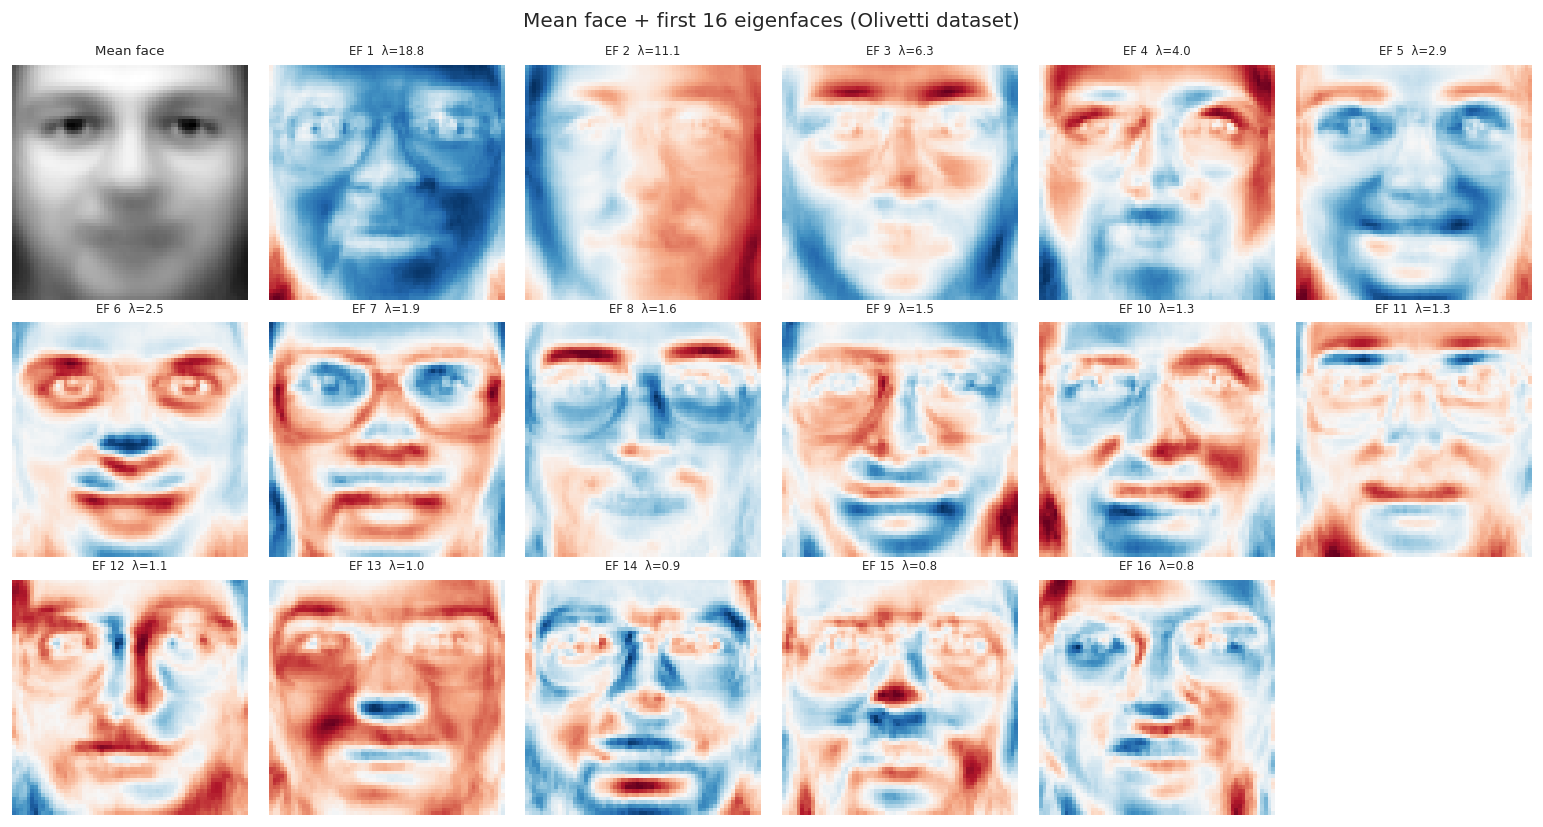

In [9]:
importlib.reload(dr)

faces = fetch_olivetti_faces(shuffle=True, random_state=SEED)
X_faces = faces.data.astype(float)        # (400, 4096) - 64x64 pixels
y_faces = faces.target                     # 0..39

print(f"Faces dataset: {X_faces.shape[0]} images, "
      f"{X_faces.shape[1]} features ({faces.images.shape[1]}x{faces.images.shape[2]} px)")
print(f"Subjects: {len(np.unique(y_faces))}")

# No StandardScaler - pixel values already [0,1]; PCA will center internally
pca_faces = dr.PCA(n_components=100)
pca_faces.fit(X_faces)

# ── Mean face ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 6, figsize=(13, 7))
axes[0, 0].imshow(pca_faces.mean_.reshape(64, 64), cmap='gray')
axes[0, 0].set_title("Mean face", fontsize=8); axes[0, 0].axis('off')

# ── First 16 eigenfaces ───────────────────────────────────────────────────────
for i, ax in enumerate(axes.flat[1:17]):
    ax.imshow(pca_faces.components_[i].reshape(64, 64), cmap='RdBu_r')
    ax.set_title(f"EF {i+1}  λ={pca_faces.explained_variance_[i]:.1f}", fontsize=7)
    ax.axis('off')

# Turn off remaining axes
for ax in axes.flat[17:]:
    ax.axis('off')

plt.suptitle("Mean face + first 16 eigenfaces (Olivetti dataset)", fontsize=12)
plt.tight_layout(); plt.show()

#### Що ви маєте бачити

**Середнє обличчя** - розмите «усереднене» обличчя без виразних деталей; це $\mu$ із формули.

**Перші власні обличчя** відображають напрямки найбільшої мінливості між людьми:
перші кілька зазвичай кодують загальну яскравість та освітлення (великі плавні градієнти),
а пізніші - дрібніші деталі (очі, ніс, контур обличчя). Зверніть увагу на двоколірну
палітру: один знак компоненти відповідає «типовому» відхиленню в один бік,
протилежний знак - у інший.

#### Завдання 4b: реконструкція обличчя при різних $k$

Порівняйте якість реконструкції при $k \in \{5, 15, 30, 60, 100\}$.

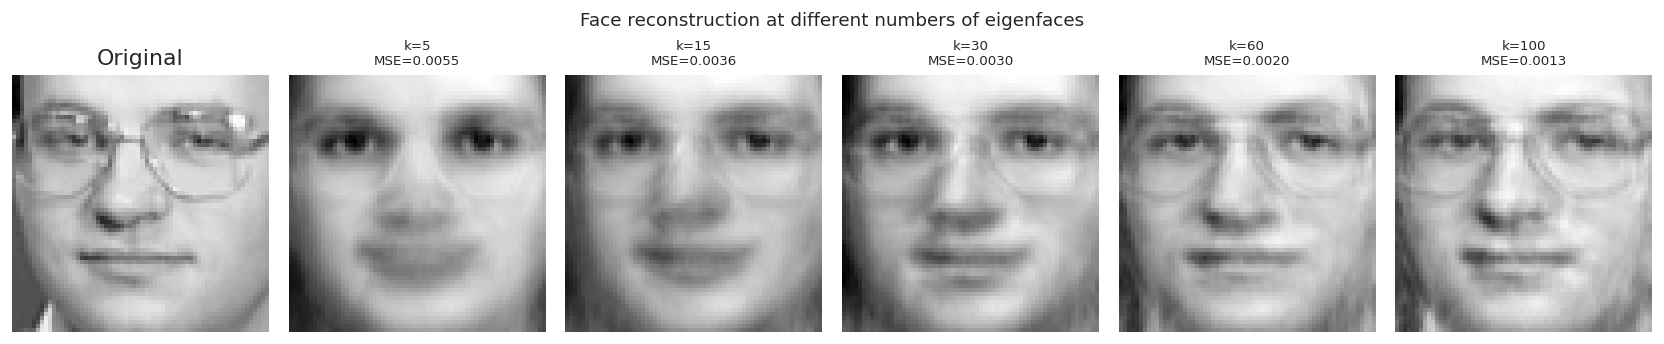

In [10]:
importlib.reload(dr)

# ── Reconstruction at varying k ───────────────────────────────────────────────
subject_idx = np.where(y_faces == 5)[0][0]   # pick first image of subject 5

k_vals_f = [5, 15, 30, 60, 100]
fig, axes = plt.subplots(1, len(k_vals_f) + 1, figsize=(14, 3))

axes[0].imshow(X_faces[subject_idx].reshape(64, 64), cmap='gray')
axes[0].set_title("Original"); axes[0].axis('off')

for ax, k in zip(axes[1:], k_vals_f):
    pca_k = dr.PCA(n_components=k)
    pca_k.fit(X_faces)
    x_hat = pca_k.inverse_transform(pca_k.transform(X_faces[[subject_idx]]))
    mse   = np.mean((X_faces[subject_idx] - x_hat[0]) ** 2)
    ax.imshow(np.clip(x_hat[0].reshape(64, 64), 0, 1), cmap='gray')
    ax.set_title(f"k={k}\nMSE={mse:.4f}", fontsize=8); ax.axis('off')

plt.suptitle("Face reconstruction at different numbers of eigenfaces", fontsize=11)
plt.tight_layout(); plt.show()

#### Що ви маєте бачити

При $k=5$ зображення ледь впізнаване - загальна форма є, але деталі відсутні.
При $k=30$–$60$ більшість характерних рис обличчя вже чітко видна при значно меншому MSE.
При $k=100$ реконструкція майже не відрізняється від оригіналу - це означає,
що 100 власних облич достатньо для компактного, але якісного представлення.

#### Завдання 4c: точність розпізнавання облич vs $k$

Виміряйте точність логістичної регресії, навченої на PCA-проекціях при різних $k$,
та порівняйте з базовою лінією на сирих пікселях.

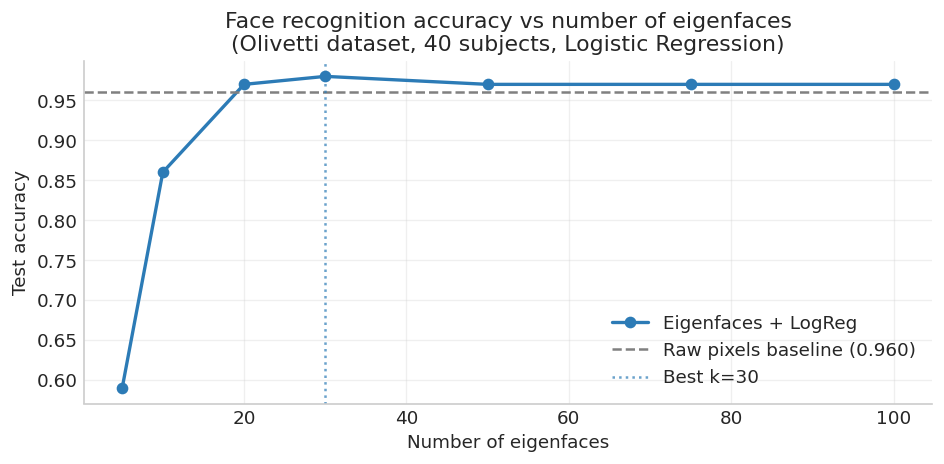

Best eigenfaces accuracy: 0.980  at k=30
Raw pixels baseline:      0.960


In [11]:
importlib.reload(dr)

# ── Face recognition accuracy vs k ───────────────────────────────────────────
X_tr_f, X_te_f, y_tr_f, y_te_f = train_test_split(
    X_faces, y_faces, test_size=0.25, stratify=y_faces, random_state=SEED)

k_range_f = [5, 10, 20, 30, 50, 75, 100]
accs_f = []

for k in k_range_f:
    pca_k = dr.PCA(n_components=k)
    Z_tr_f = pca_k.fit_transform(X_tr_f)
    Z_te_f = pca_k.transform(X_te_f)
    clf_f  = SklearnLR(max_iter=1000, C=5, random_state=SEED)
    clf_f.fit(Z_tr_f, y_tr_f)
    accs_f.append(accuracy_score(y_te_f, clf_f.predict(Z_te_f)))

clf_raw = SklearnLR(max_iter=1000, C=5, random_state=SEED)
clf_raw.fit(X_tr_f, y_tr_f)
baseline_f = accuracy_score(y_te_f, clf_raw.predict(X_te_f))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_range_f, accs_f, marker='o', color=COLORS[0], lw=2, label="Eigenfaces + LogReg")
ax.axhline(baseline_f, linestyle='--', color='gray', lw=1.5,
           label=f"Raw pixels baseline ({baseline_f:.3f})")
best_k = k_range_f[int(np.argmax(accs_f))]
ax.axvline(best_k, linestyle=':', color=COLORS[0], alpha=0.7,
           label=f"Best k={best_k}")
ax.set_xlabel("Number of eigenfaces"); ax.set_ylabel("Test accuracy")
ax.set_title("Face recognition accuracy vs number of eigenfaces\n"
             "(Olivetti dataset, 40 subjects, Logistic Regression)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"Best eigenfaces accuracy: {max(accs_f):.3f}  at k={best_k}")
print(f"Raw pixels baseline:      {baseline_f:.3f}")

#### Що ви маєте бачити

Точність стрімко зростає при малих $k$ і виходить на плато десь після $k=30$–$50$.
Базова лінія (сирі пікселі) зазвичай нижча або порівнянна - логістична регресія
на 4096 ознаках погано обумовлена без регуляризації, тоді як PCA-проекція природно
знімає надлишкові та шумові виміри. Найвища точність, як правило, досягається
при $k$ значно меншому за кількість ознак.

---
## 5. - Шумоподавлення сигналів за допомогою SVD

Один із практичних застосунків Truncated SVD - **шумоподавлення** (denoising).

Ідея: якщо матриця $X$ є сумою корисного сигналу низького рангу $S$ та шуму $N$:

$$X = S + N, \quad \text{rank}(S) = r \ll \min(n, d)$$

то $\hat{X}_r = U_r \Sigma_r V_r^\top$ є найкращим наближенням ранг-$r$ і,
за умови невеликого шуму, добре відновлює $S$, відкидаючи шум (який «розподіляється»
рівномірно по малим сингулярним значенням).

### Завдання
Застосувати TruncatedSVD до матриці зашумлених сигналів і порівняти якість
відновлення при різних рівнях шуму та значеннях $k$.

#### Завдання 5a: матриця шумоподавлення

Застосуйте `TruncatedSVD` до зашумленої матриці сигналів при різних рівнях шуму
та різних $k$. Порівняйте візуально відновлений сигнал із зашумленим.

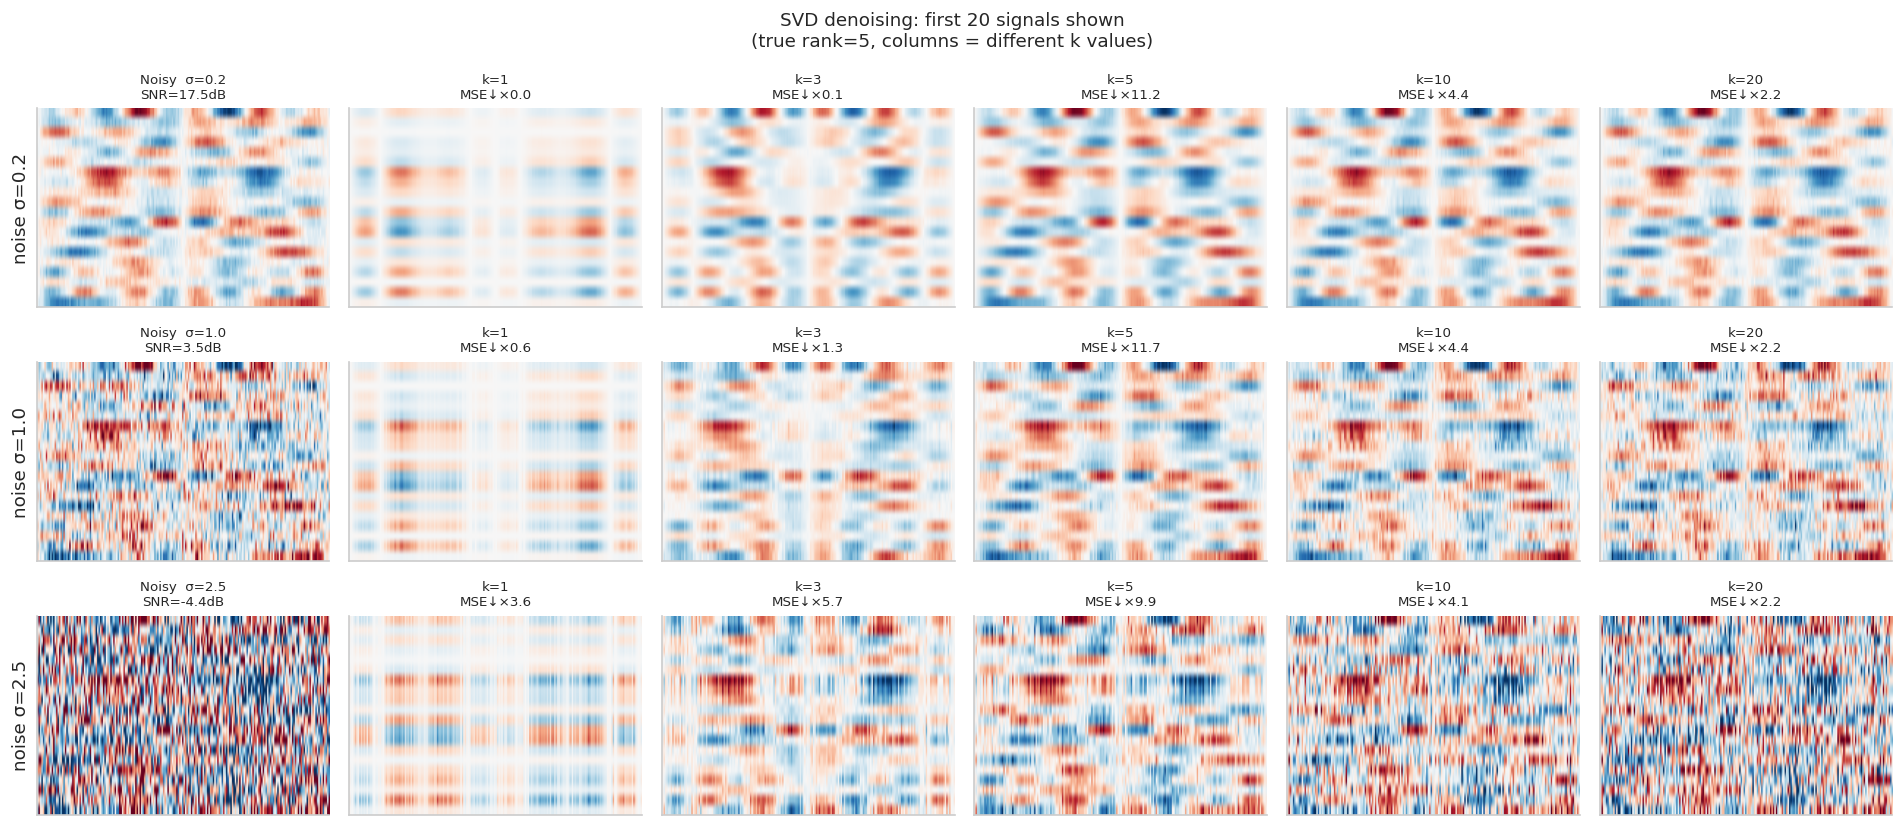

In [12]:
importlib.reload(dr)

# ── Generate a low-rank signal matrix ─────────────────────────────────────────
rng = np.random.default_rng(SEED)

n_signals, n_timepoints, true_rank = 80, 200, 5

# Low-rank "true" signal: outer product of 5 patterns
U_true  = rng.normal(size=(n_signals, true_rank))
V_true  = np.vstack([np.sin(np.linspace(0, (j+1)*np.pi*2, n_timepoints))
                     for j in range(true_rank)]).T       # (n_timepoints, true_rank)
S_clean = U_true @ V_true.T                              # (n_signals, n_timepoints)

noise_levels = [0.2, 1.0, 2.5]
k_denoise    = [1, 3, 5, 10, 20]

fig, axes = plt.subplots(len(noise_levels), len(k_denoise) + 1,
                         figsize=(16, 7))

for row, sigma in enumerate(noise_levels):
    X_noisy = S_clean + rng.normal(scale=sigma, size=S_clean.shape)
    snr = 10 * np.log10(np.var(S_clean) / sigma**2)

    axes[row, 0].imshow(X_noisy[:20], aspect='auto', cmap='RdBu_r',
                        vmin=-4, vmax=4)
    axes[row, 0].set_title(f"Noisy  σ={sigma}\nSNR={snr:.1f}dB", fontsize=8)
    axes[row, 0].set_ylabel(f"noise σ={sigma}")

    for col, k in enumerate(k_denoise, start=1):
        svd_k = dr.TruncatedSVD(n_components=k)
        svd_k.fit(X_noisy)
        X_denoised = svd_k.inverse_transform(svd_k.transform(X_noisy))
        mse_noisy  = np.mean((S_clean - X_noisy)     ** 2)
        mse_denoised = np.mean((S_clean - X_denoised) ** 2)
        gain = mse_noisy / (mse_denoised + 1e-12)

        axes[row, col].imshow(X_denoised[:20], aspect='auto', cmap='RdBu_r',
                              vmin=-4, vmax=4)
        axes[row, col].set_title(f"k={k}\nMSE↓×{gain:.1f}", fontsize=8)

for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle("SVD denoising: first 20 signals shown\n"
             "(true rank=5, columns = different k values)", fontsize=11)
plt.tight_layout(); plt.show()

#### Що ви маєте бачити

При малому шумі ($\sigma=0.2$) вже $k=5$ (справжній ранг сигналу) дає майже ідеальне відновлення.
При великому шумі ($\sigma=2.5$) і малих $k$ залишається значний залишок - сигнал «загублено»
у шумі. Збільшення $k$ понад справжній ранг починає «добирати» шум замість сигналу:
зображення стає гіршим, а не кращим. Оптимум - рівно навколо $k = 5$.

#### Завдання 5b: MSE vs $k$ для різних рівнів шуму

Побудуйте криві MSE (відносно чистого сигналу) залежно від $k$ для трьох рівнів шуму.

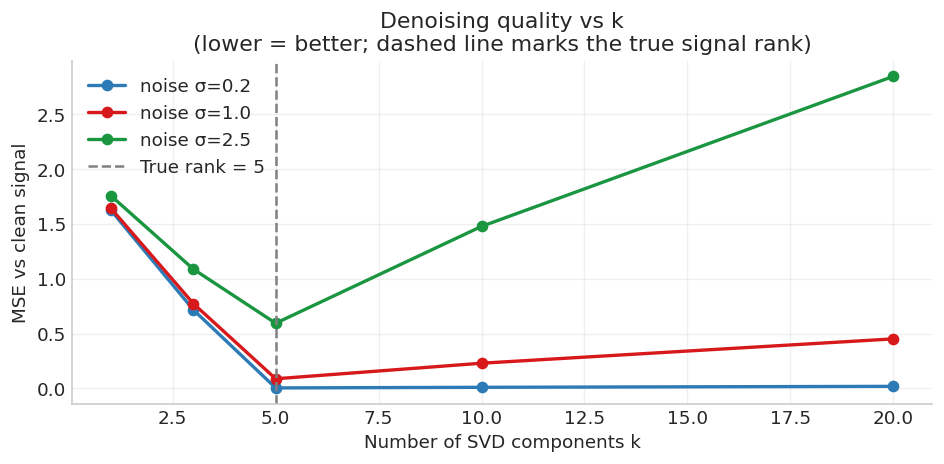

Observation: best denoising occurs near k = true_rank.
Over-estimating k re-introduces noise; under-estimating loses signal.


In [13]:
importlib.reload(dr)

# ── MSE vs k for different noise levels ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

for sigma, color in zip(noise_levels, COLORS[:3]):
    X_noisy = S_clean + rng.normal(scale=sigma, size=S_clean.shape)
    mse_vals = []
    for k in k_denoise:
        svd_k = dr.TruncatedSVD(n_components=k)
        svd_k.fit(X_noisy)
        X_den = svd_k.inverse_transform(svd_k.transform(X_noisy))
        mse_vals.append(np.mean((S_clean - X_den) ** 2))
    ax.plot(k_denoise, mse_vals, marker='o', color=color, lw=2,
            label=f"noise σ={sigma}")

ax.axvline(true_rank, linestyle='--', color='gray', lw=1.5,
           label=f"True rank = {true_rank}")
ax.set_xlabel("Number of SVD components k")
ax.set_ylabel("MSE vs clean signal")
ax.set_title("Denoising quality vs k\n"
             "(lower = better; dashed line marks the true signal rank)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("Observation: best denoising occurs near k = true_rank.")
print("Over-estimating k re-introduces noise; under-estimating loses signal.")

#### Що ви маєте бачити

Кожна крива має мінімум поблизу вертикальної пунктирної лінії $k = \text{true rank} = 5$.
Зліва від мінімуму модель занадто «стиснута» і втрачає частину сигналу.
Справа - вона починає включати шумові компоненти, і MSE зростає.
При вищому рівні шуму мінімум менш виражений і зміщений ближче до меншого $k$,
оскільки шум «розмиває» межу між сигналом і шумом у спектрі сингулярних значень.

---
## Підсумок

| Тема | Ключовий висновок |
|------|-------------------|
| **PCA (fit)** | Власні вектори коваріаційної матриці задають напрямки максимальної дисперсії |
| **Реконструкція** | $\hat{X} = Z V_k^\top + \mu$; похибка монотонно спадає з ростом $k$ |
| **Вибір $k$** | Scree plot та поріг 90–95% EVR - практичний орієнтир |
| **TruncatedSVD** | Еквівалентна PCA на центрованих даних; $\lambda_i = \sigma_i^2/(n-1)$ |
| **Eckart-Young** | Похибка truncated SVD точно дорівнює $\sum_{i>k} \sigma_i^2 / (nd)$ |
| **Eigenfaces** | PCA на зображеннях - компактне представлення; $k \approx 30{-}50$ замість 4096 ознак |
| **Шумоподавлення** | Оптимальне $k \approx$ справжній ранг сигналу; надмірне $k$ повертає шум |